# PRCP-1014: Vaccine Prediction — Complete ML Pipeline
### Predicting H1N1 & Seasonal Flu Vaccine Uptake

**Project by:** Trivedi Jaishil Ketanbhai  
**Dataset:** PRCP-1014-VaccinePred  
**Objective:** Build predictive models to identify individuals likely to receive H1N1 and seasonal flu vaccines, and select the best model for production deployment.

---
> **Tasks Covered:**
> - ✅ Task 1: Complete Data Analysis Report (EDA)
> - ✅ Task 2: Predictive Modelling (5+ models trained)
> - ✅ Model Comparison Report
> - ✅ Challenges Report
> - ✅ Best Model saved via Pickle


## 1. Import Libraries
We begin by importing all necessary libraries for data analysis, visualisation, machine learning, and model persistence.

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("Blues_d")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)

# Pickle for model saving
import pickle

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__} | Numpy version: {np.__version__}")


✅ All libraries imported successfully!
Pandas version: 2.2.3 | Numpy version: 2.1.3


## 2. Load Dataset
We load the features and labels CSVs separately and merge them on `respondent_id`. This gives us one unified dataframe for analysis.

In [2]:
# Load features and labels
features = pd.read_csv('features.csv')
labels   = pd.read_csv('labels.csv')

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")

# Merge on respondent_id
df = features.merge(labels, on='respondent_id', how='inner')
print(f"Merged dataset : {df.shape}")
df.head()


Features shape : (26707, 36)
Labels shape   : (26707, 3)
Merged dataset : (26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Dataset Overview
We examine the structure, data types, and a statistical summary to understand what we're working with.


In [3]:
# Shape and types
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()
print("Data Types:")
print(df.dtypes.value_counts())
print()
df.info()


Rows: 26,707  |  Columns: 38

Data Types:
float64    23
object     12
int64       3
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal 

In [4]:
# Statistical Summary — numerical columns
df.describe(include='number').T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.000000,13353.000000,7709.791156,0.000000,6676.500000,13353.000000,20029.500000,26706.000000
h1n1_concern,26615.000000,1.618486,0.910311,0.000000,1.000000,2.000000,2.000000,3.000000
h1n1_knowledge,26591.000000,1.262532,0.618149,0.000000,1.000000,1.000000,2.000000,2.000000
behavioral_antiviral_meds,26636.000000,0.048844,0.215545,0.000000,0.000000,0.000000,0.000000,1.000000
behavioral_avoidance,26499.000000,0.725612,0.446214,0.000000,0.000000,1.000000,1.000000,1.000000
behavioral_face_mask,26688.000000,0.068982,0.253429,0.000000,0.000000,0.000000,0.000000,1.000000
behavioral_wash_hands,26665.000000,0.825614,0.379448,0.000000,1.000000,1.000000,1.000000,1.000000
behavioral_large_gatherings,26620.000000,0.358640,0.479610,0.000000,0.000000,0.000000,1.000000,1.000000
behavioral_outside_home,26625.000000,0.337315,0.472802,0.000000,0.000000,0.000000,1.000000,1.000000
behavioral_touch_face,26579.000000,0.677264,0.467531,0.000000,0.000000,1.000000,1.000000,1.000000


### 3.2 Target Variable Distribution
Understanding class balance is critical before modelling. Imbalanced targets can skew model predictions.

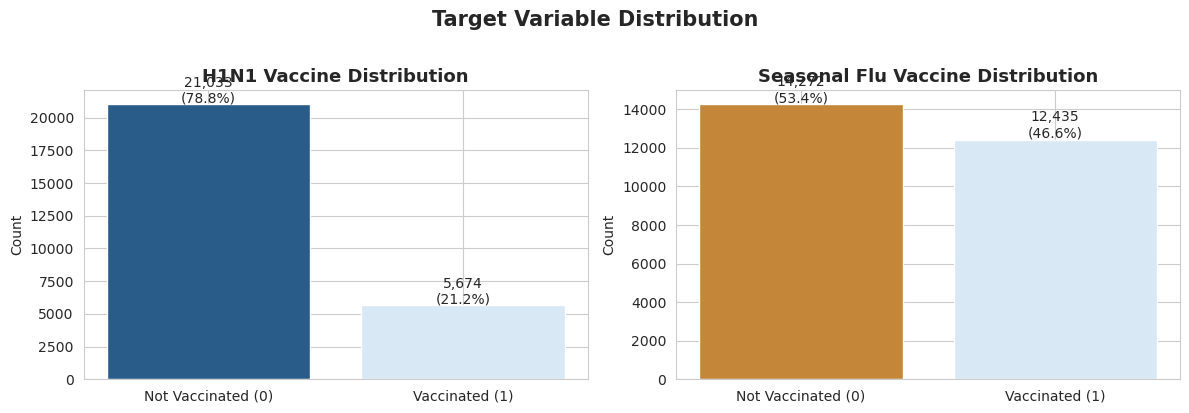

H1N1 Vaccination Rate    : 21.2%
Seasonal Vaccination Rate: 46.6%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title, color in zip(
    axes,
    ['h1n1_vaccine', 'seasonal_vaccine'],
    ['H1N1 Vaccine', 'Seasonal Flu Vaccine'],
    ['#2A5C8A', '#C4873A']
):
    counts = df[col].value_counts()
    ax.bar(['Not Vaccinated (0)', 'Vaccinated (1)'], counts.values, color=[color, '#D9E8F5'])
    ax.set_title(f'{title} Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"H1N1 Vaccination Rate    : {df['h1n1_vaccine'].mean()*100:.1f}%")
print(f"Seasonal Vaccination Rate: {df['seasonal_vaccine'].mean()*100:.1f}%")


### 3.3 Missing Value Analysis
Many real-world datasets have missing values. We identify them before deciding on imputation strategies.

                             Missing Count  Missing %
employment_occupation                13470      50.44
employment_industry                  13330      49.91
health_insurance                     12274      45.96
income_poverty                        4423      16.56
doctor_recc_seasonal                  2160       8.09
doctor_recc_h1n1                      2160       8.09
rent_or_own                           2042       7.65
employment_status                     1463       5.48
marital_status                        1408       5.27
education                             1407       5.27
chronic_med_condition                  971       3.64
child_under_6_months                   820       3.07
health_worker                          804       3.01
opinion_seas_sick_from_vacc            537       2.01
opinion_seas_risk                      514       1.92
opinion_seas_vacc_effective            462       1.73
opinion_h1n1_sick_from_vacc            395       1.48
opinion_h1n1_vacc_effective 

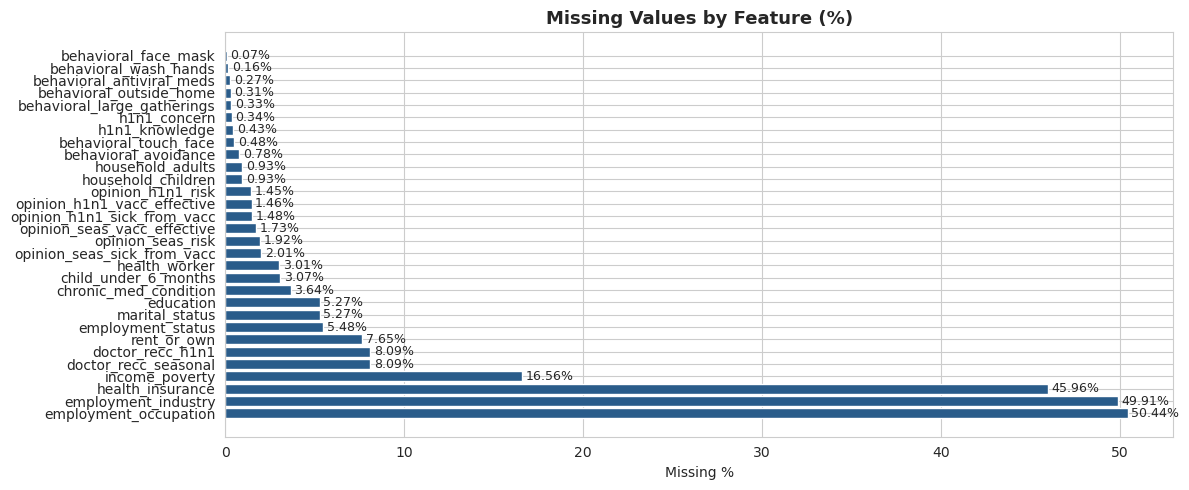

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#2A5C8A', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature (%)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 3.4 Feature Distributions — Behavioural & Opinion Features

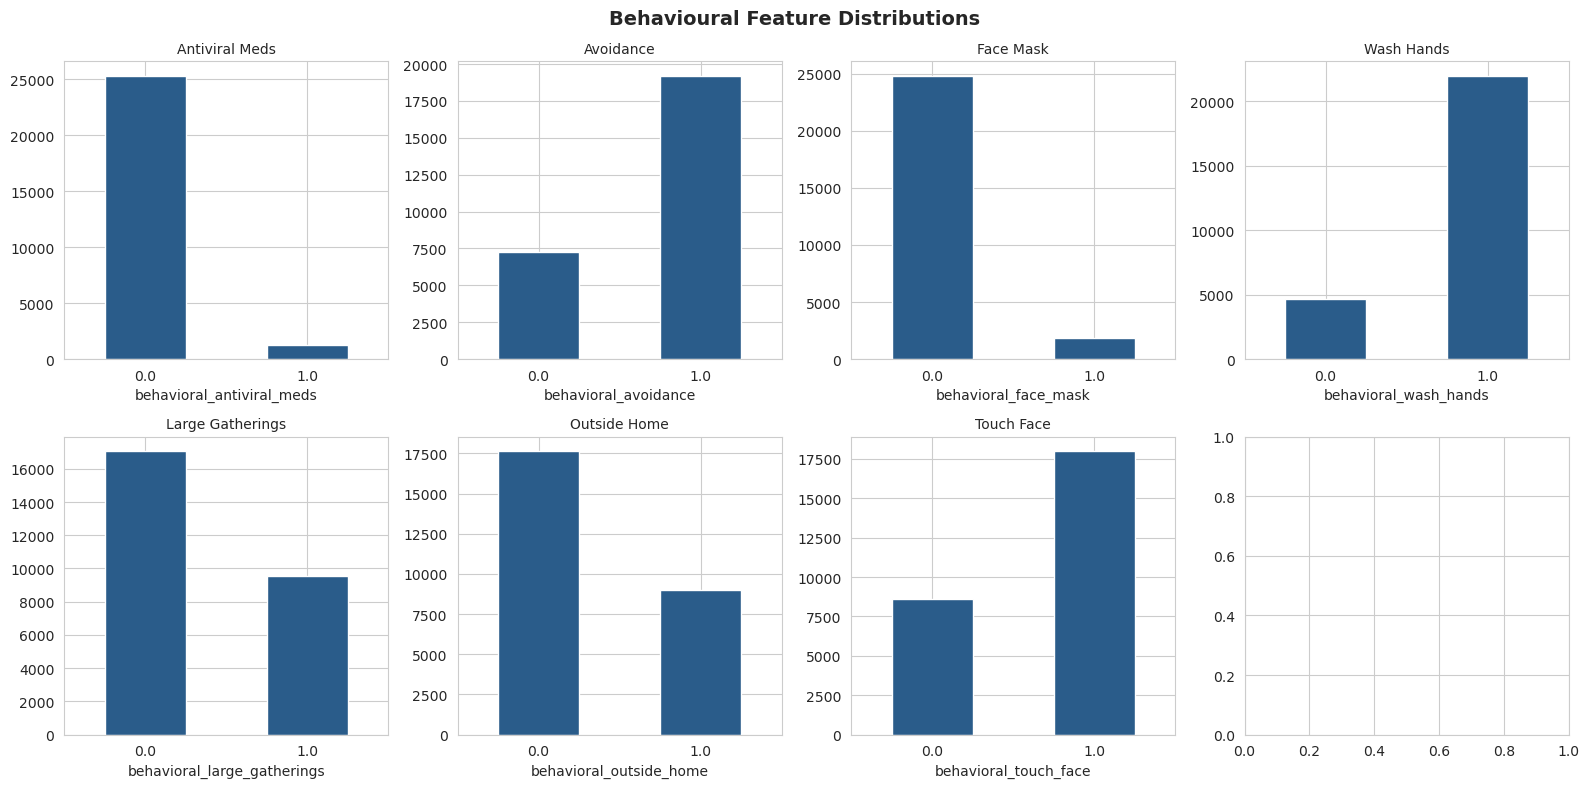

In [7]:
behavioral_cols = [c for c in df.columns if c.startswith('behavioral_')]
opinion_cols    = [c for c in df.columns if c.startswith('opinion_')]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), behavioral_cols[:8]):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#2A5C8A', edgecolor='white')
    ax.set_title(col.replace('behavioral_', '').replace('_', ' ').title(), fontsize=10)
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Behavioural Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.5 Categorical Feature Analysis

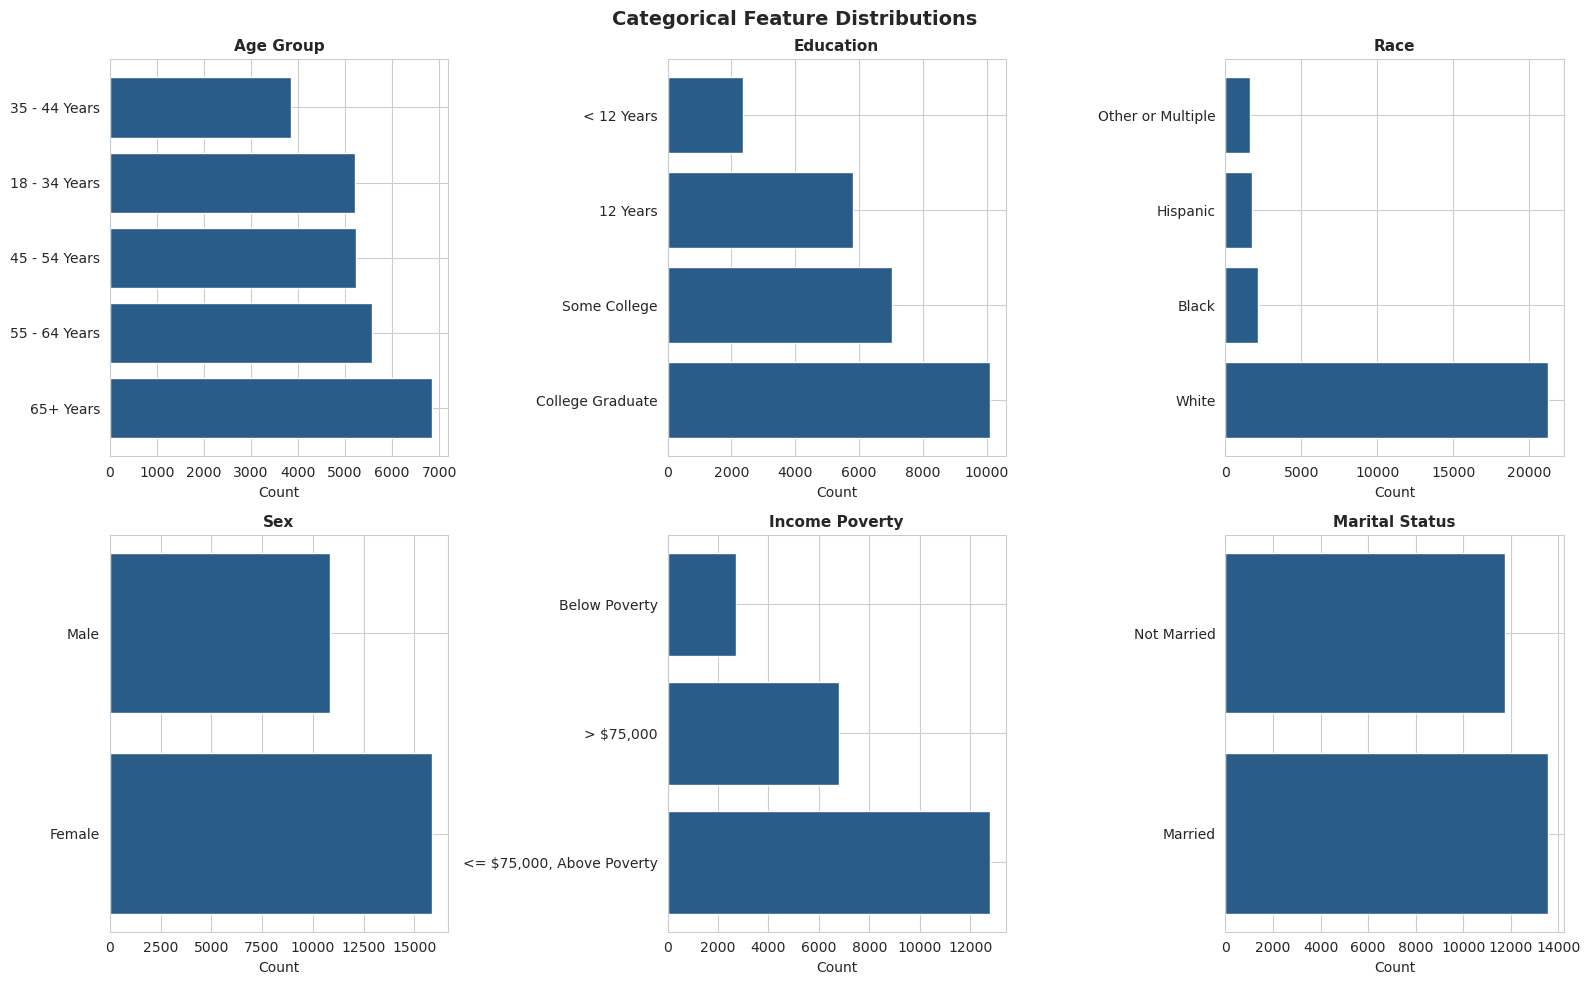

In [8]:
cat_cols = ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts()
    ax.barh(vc.index, vc.values, color='#2A5C8A')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.6 Vaccination Rate by Key Categories
Understanding which demographic groups have higher vaccination rates helps interpret model feature importance.

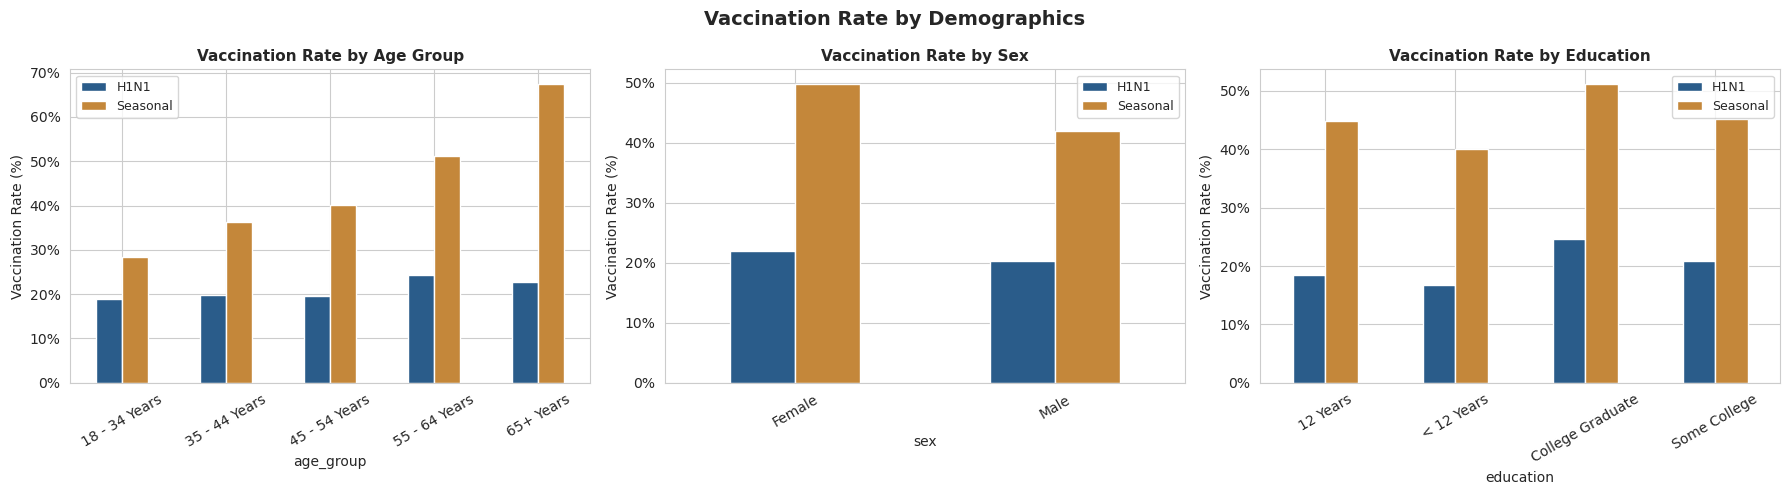

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['age_group', 'sex', 'education']):
    grp = df.groupby(col)[['h1n1_vaccine', 'seasonal_vaccine']].mean() * 100
    grp.plot(kind='bar', ax=ax, color=['#2A5C8A', '#C4873A'], edgecolor='white', rot=30)
    ax.set_title(f'Vaccination Rate by {col.replace("_"," ").title()}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Vaccination Rate (%)')
    ax.legend(['H1N1', 'Seasonal'], fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Vaccination Rate by Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.7 Correlation Heatmap — Numerical Features

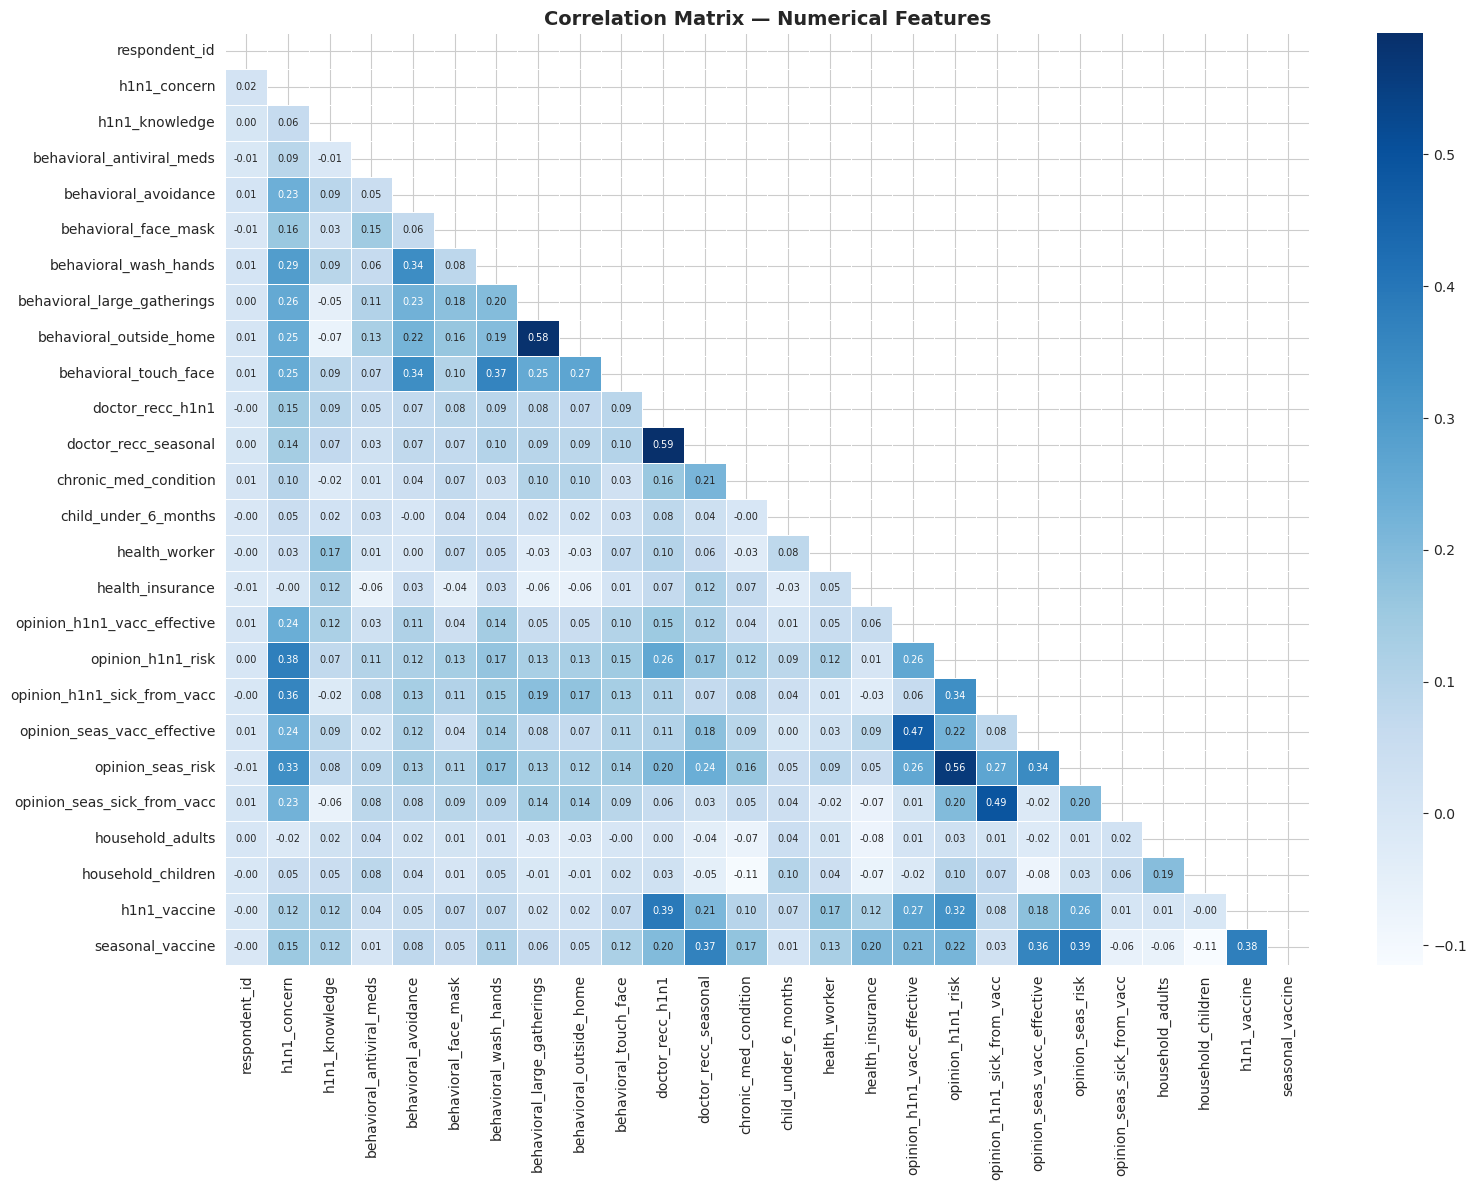

Top correlations with h1n1_vaccine:
h1n1_vaccine                   1.000000
doctor_recc_h1n1               0.393890
seasonal_vaccine               0.377143
opinion_h1n1_risk              0.323265
opinion_h1n1_vacc_effective    0.269347
opinion_seas_risk              0.258571
doctor_recc_seasonal           0.209864
opinion_seas_vacc_effective    0.179272
health_worker                  0.169768
h1n1_concern                   0.121929
Name: h1n1_vaccine, dtype: float64


In [10]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print("Top correlations with h1n1_vaccine:")
print(corr['h1n1_vaccine'].abs().sort_values(ascending=False).head(10))


## 4. Data Preprocessing
### 4.1 Define Features and Targets
We separate our feature matrix (X) and target variables (y). Since we have two targets (H1N1 and Seasonal), this is a **multi-label classification** problem — but we will train separate models for each target for clarity.


In [11]:
# Drop respondent_id — not a predictor
X = df.drop(columns=['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'])
y_h1n1     = df['h1n1_vaccine']
y_seasonal = df['seasonal_vaccine']

print(f"Feature matrix X : {X.shape}")
print(f"H1N1 target      : {y_h1n1.shape}  |  Class balance: {y_h1n1.mean():.3f}")
print(f"Seasonal target  : {y_seasonal.shape}  |  Class balance: {y_seasonal.mean():.3f}")


Feature matrix X : (26707, 35)
H1N1 target      : (26707,)  |  Class balance: 0.212
Seasonal target  : (26707,)  |  Class balance: 0.466


### 4.2 Identify Column Types

In [12]:
# Numerical and categorical columns
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(num_features)}): {num_features}")
print()
print(f"Categorical features ({len(cat_features)}): {cat_features}")


Numerical features (23): ['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Categorical features (12): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']


### 4.3 Build Preprocessing Pipeline
We use `sklearn` Pipelines to:
- **Numerical features**: Impute missing values with the median (robust to outliers), then scale with StandardScaler
- **Categorical features**: Impute missing with most frequent value, then One-Hot Encode

In [13]:
# Numerical pipeline: median imputation + standard scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: mode imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

print("✅ Preprocessing pipeline built successfully!")
print("  - Numerical : Median Imputation → StandardScaler")
print("  - Categorical: Mode Imputation  → OneHotEncoder")


✅ Preprocessing pipeline built successfully!
  - Numerical : Median Imputation → StandardScaler
  - Categorical: Mode Imputation  → OneHotEncoder


### 4.4 Train-Test Split
We split the data 80/20 using stratification to preserve class proportions in both splits.

In [14]:
X_train, X_test, y_h1n1_train, y_h1n1_test, y_seas_train, y_seas_test = train_test_split(
    X, y_h1n1, y_seasonal,
    test_size=0.2,
    random_state=42,
    stratify=y_h1n1  # stratify on H1N1 target
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"H1N1 train balance   : {y_h1n1_train.mean():.3f}")
print(f"Seasonal train balance: {y_seas_train.mean():.3f}")


Training set   : 21,365 rows
Test set       : 5,342 rows
H1N1 train balance   : 0.212
Seasonal train balance: 0.464


## 5. Model Training & Evaluation
We train **5 different classifiers** on the H1N1 vaccine prediction task (primary target), then also evaluate on seasonal vaccine. For each model, we report:
- **Accuracy** — overall correctness
- **ROC-AUC** — ability to distinguish vaccinated vs not (primary metric for this problem)
- **Classification Report** — Precision, Recall, F1 per class
- **Confusion Matrix**

The **ROC-AUC** is our primary evaluation metric because the dataset is slightly imbalanced and we care about ranking/probability quality.


### 5.1 Define All Models

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42,
                                         use_label_encoder=False, eval_metric='logloss', verbosity=0)
}

print("✅ Models configured:")
for name in models:
    print(f"   • {name}")


✅ Models configured:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • XGBoost


### 5.2 Train and Evaluate All Models
For each model we fit the full pipeline (preprocessor + classifier), predict on the test set, and log all metrics.

In [16]:
results = {}

for name, clf in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")
    
    # Build full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # ----- H1N1 -----
    pipeline.fit(X_train, y_h1n1_train)
    y_pred_h1n1  = pipeline.predict(X_test)
    y_prob_h1n1  = pipeline.predict_proba(X_test)[:, 1]
    acc_h1n1     = accuracy_score(y_h1n1_test, y_pred_h1n1)
    auc_h1n1     = roc_auc_score(y_h1n1_test, y_prob_h1n1)
    
    # ----- Seasonal -----
    pipeline.fit(X_train, y_seas_train)
    y_pred_seas  = pipeline.predict(X_test)
    y_prob_seas  = pipeline.predict_proba(X_test)[:, 1]
    acc_seas     = accuracy_score(y_seas_test, y_pred_seas)
    auc_seas     = roc_auc_score(y_seas_test, y_prob_seas)
    
    results[name] = {
        'h1n1_acc': acc_h1n1, 'h1n1_auc': auc_h1n1,
        'seas_acc': acc_seas,  'seas_auc': auc_seas,
        'mean_auc': (auc_h1n1 + auc_seas) / 2
    }
    
    print(f"  H1N1     → Accuracy: {acc_h1n1:.4f}  |  ROC-AUC: {auc_h1n1:.4f}")
    print(f"  Seasonal → Accuracy: {acc_seas:.4f}  |  ROC-AUC: {auc_seas:.4f}")
    print(f"  Mean AUC : {results[name]['mean_auc']:.4f}")

print("\n✅ All models trained and evaluated!")



  Training: Logistic Regression
  H1N1     → Accuracy: 0.8368  |  ROC-AUC: 0.8288
  Seasonal → Accuracy: 0.7840  |  ROC-AUC: 0.8552
  Mean AUC : 0.8420

  Training: Decision Tree
  H1N1     → Accuracy: 0.8210  |  ROC-AUC: 0.7961
  Seasonal → Accuracy: 0.7591  |  ROC-AUC: 0.8249
  Mean AUC : 0.8105

  Training: Random Forest
  H1N1     → Accuracy: 0.8353  |  ROC-AUC: 0.8228
  Seasonal → Accuracy: 0.7810  |  ROC-AUC: 0.8516
  Mean AUC : 0.8372

  Training: Gradient Boosting
  H1N1     → Accuracy: 0.8385  |  ROC-AUC: 0.8346
  Seasonal → Accuracy: 0.7939  |  ROC-AUC: 0.8607
  Mean AUC : 0.8477

  Training: XGBoost
  H1N1     → Accuracy: 0.8370  |  ROC-AUC: 0.8330
  Seasonal → Accuracy: 0.7907  |  ROC-AUC: 0.8589
  Mean AUC : 0.8460

✅ All models trained and evaluated!


## 6. Model Comparison Report
We compare all models side-by-side across four metrics. This is our formal **Model Comparison Report** as required in the project.

In [17]:
# Build comparison dataframe
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'H1N1 Accuracy', 'H1N1 ROC-AUC', 'Seasonal Accuracy', 'Seasonal ROC-AUC', 'Mean AUC']
results_df = results_df.sort_values('Mean AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 80)
print("MODEL COMPARISON REPORT")
print("=" * 80)
print(results_df.to_string(index=True, float_format=lambda x: f'{x:.4f}'))
print("=" * 80)
print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}  |  Mean AUC: {results_df.iloc[0]['Mean AUC']:.4f}")


MODEL COMPARISON REPORT
                 Model  H1N1 Accuracy  H1N1 ROC-AUC  Seasonal Accuracy  Seasonal ROC-AUC  Mean AUC
1    Gradient Boosting         0.8385        0.8346             0.7939            0.8607    0.8477
2              XGBoost         0.8370        0.8330             0.7907            0.8589    0.8460
3  Logistic Regression         0.8368        0.8288             0.7840            0.8552    0.8420
4        Random Forest         0.8353        0.8228             0.7810            0.8516    0.8372
5        Decision Tree         0.8210        0.7961             0.7591            0.8249    0.8105

🏆 Best Model: Gradient Boosting  |  Mean AUC: 0.8477


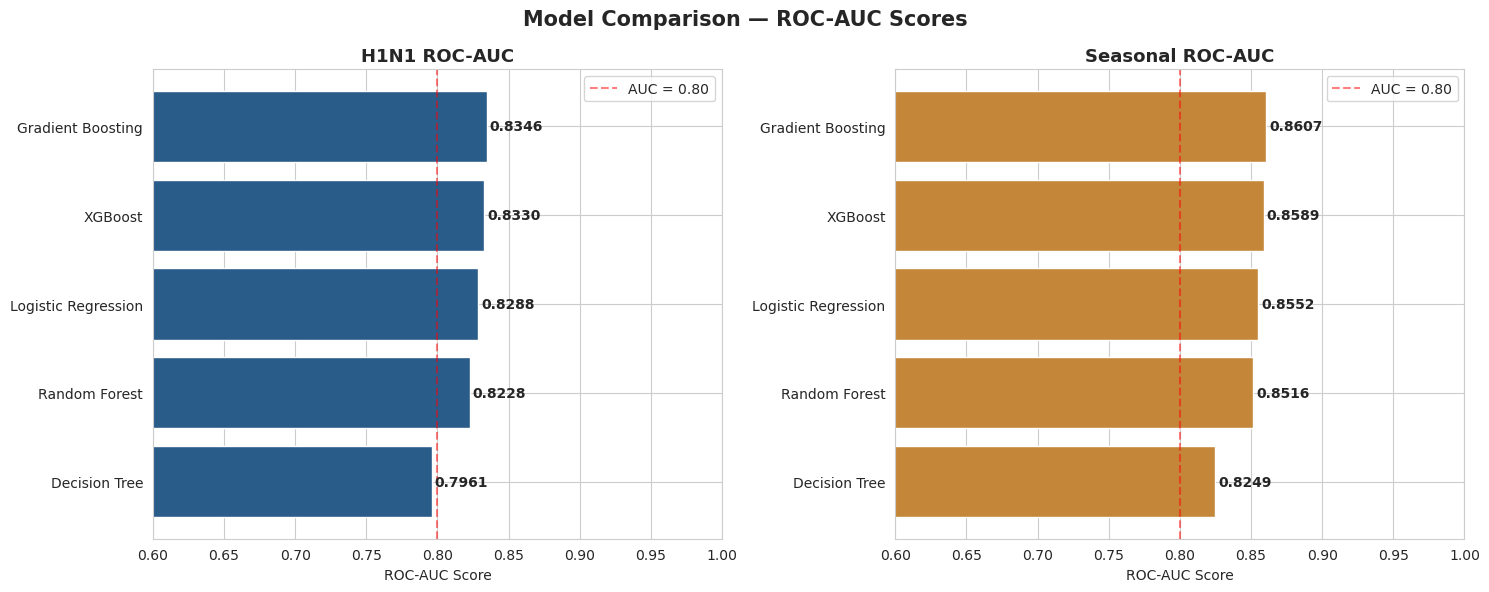

In [18]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metrics = [('H1N1 ROC-AUC', '#2A5C8A'), ('Seasonal ROC-AUC', '#C4873A')]
for ax, (metric, color) in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='white')
    ax.set_xlim(0.6, 1.0)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('ROC-AUC Score')
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.axvline(x=0.8, linestyle='--', color='red', alpha=0.5, label='AUC = 0.80')
    ax.legend()

plt.suptitle('Model Comparison — ROC-AUC Scores', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


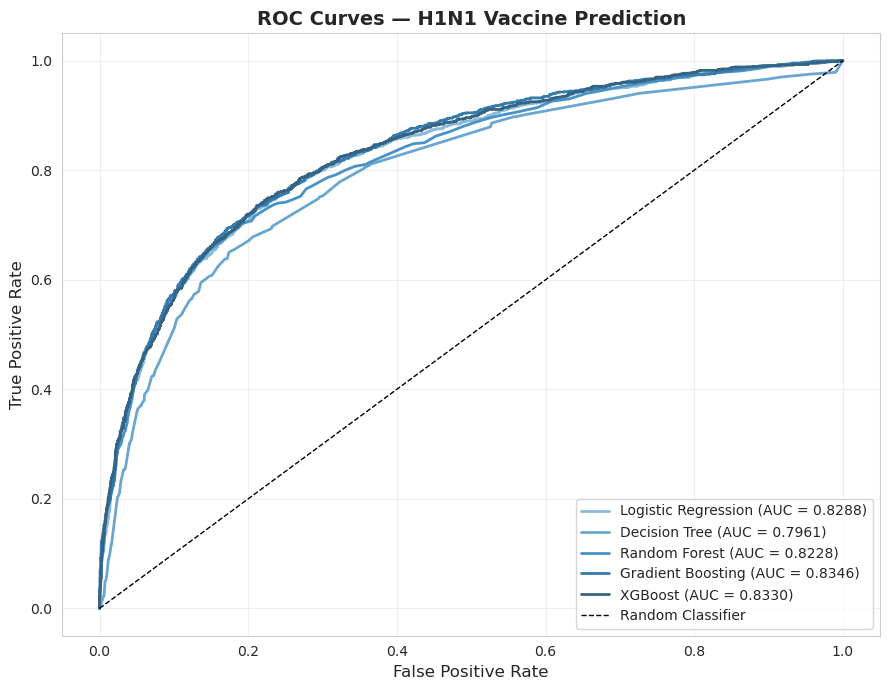

In [19]:
# ROC Curves for H1N1 — all models on same plot
plt.figure(figsize=(9, 7))

for name, clf in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipeline.fit(X_train, y_h1n1_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_h1n1_test, y_prob)
    auc = roc_auc_score(y_h1n1_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — H1N1 Vaccine Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Best Model — Detailed Analysis
Based on the highest Mean ROC-AUC, we select the best model and perform a detailed evaluation including confusion matrices, classification reports, and feature importance.

In [20]:
best_model_name = results_df.iloc[0]['Model']
print(f"🏆 Selected Best Model: {best_model_name}")
print(f"   H1N1 ROC-AUC     : {results_df.iloc[0]['H1N1 ROC-AUC']:.4f}")
print(f"   Seasonal ROC-AUC : {results_df.iloc[0]['Seasonal ROC-AUC']:.4f}")
print(f"   Mean ROC-AUC     : {results_df.iloc[0]['Mean AUC']:.4f}")


🏆 Selected Best Model: Gradient Boosting
   H1N1 ROC-AUC     : 0.8346
   Seasonal ROC-AUC : 0.8607
   Mean ROC-AUC     : 0.8477


In [21]:
# Re-train best model on H1N1 and Seasonal
best_clf = models[best_model_name]

# H1N1 pipeline
best_pipeline_h1n1 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_clf)])
best_pipeline_h1n1.fit(X_train, y_h1n1_train)
y_pred_h1n1 = best_pipeline_h1n1.predict(X_test)
y_prob_h1n1 = best_pipeline_h1n1.predict_proba(X_test)[:, 1]

# Seasonal pipeline
best_pipeline_seas = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_clf)])
best_pipeline_seas.fit(X_train, y_seas_train)
y_pred_seas = best_pipeline_seas.predict(X_test)
y_prob_seas = best_pipeline_seas.predict_proba(X_test)[:, 1]

print("H1N1 Classification Report:")
print(classification_report(y_h1n1_test, y_pred_h1n1, target_names=['Not Vaccinated','Vaccinated']))
print("\nSeasonal Classification Report:")
print(classification_report(y_seas_test, y_pred_seas, target_names=['Not Vaccinated','Vaccinated']))


H1N1 Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.87      0.94      0.90      4207
    Vaccinated       0.68      0.46      0.55      1135

      accuracy                           0.84      5342
     macro avg       0.77      0.70      0.72      5342
  weighted avg       0.83      0.84      0.83      5342


Seasonal Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.80      0.82      0.81      2822
    Vaccinated       0.79      0.77      0.78      2520

      accuracy                           0.79      5342
     macro avg       0.79      0.79      0.79      5342
  weighted avg       0.79      0.79      0.79      5342



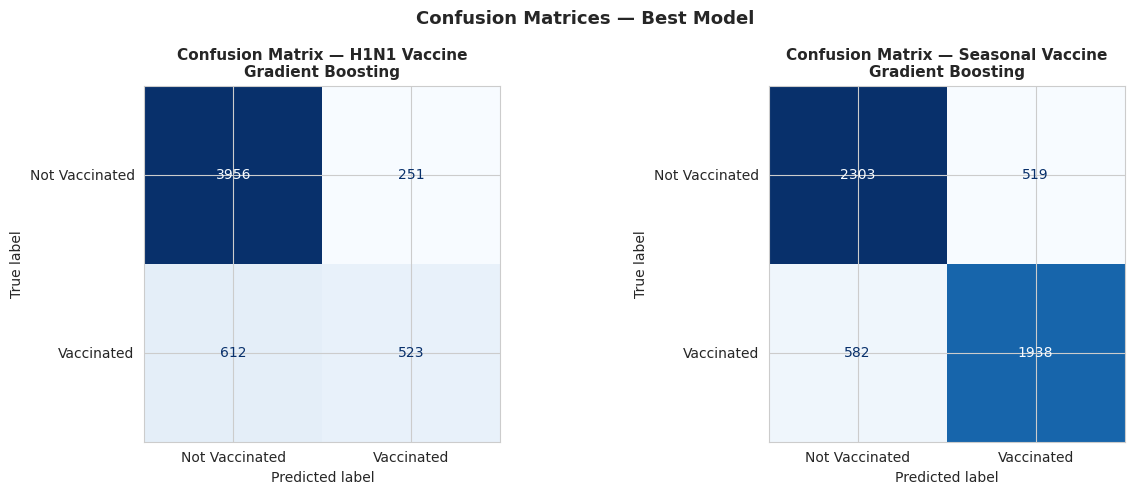

In [22]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_h1n1_test, y_seas_test],
    [y_pred_h1n1, y_pred_seas],
    ['H1N1 Vaccine', 'Seasonal Vaccine']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Vaccinated', 'Vaccinated'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}\n{best_model_name}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Best Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


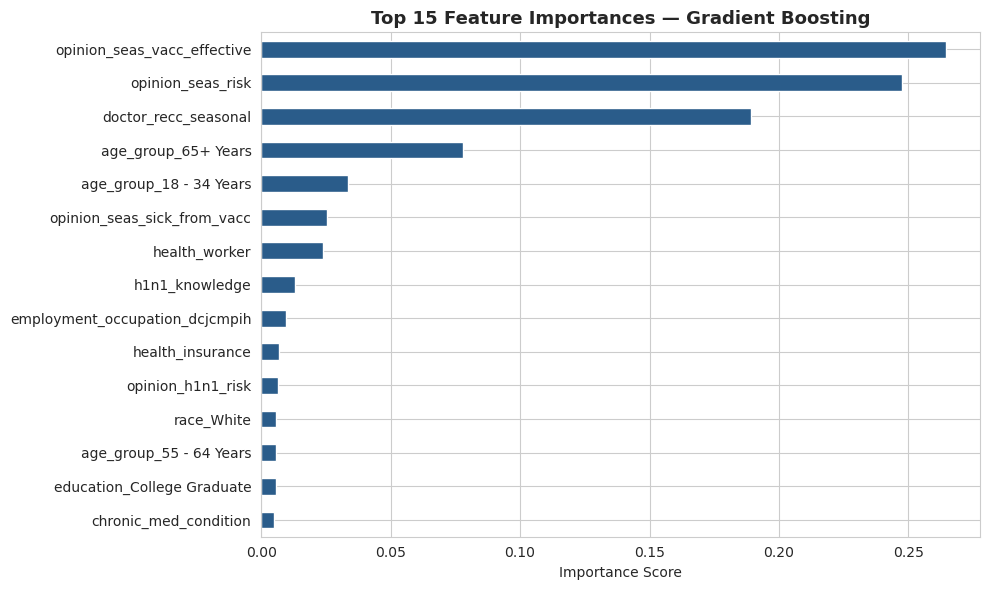

Top 10 Most Important Features:
opinion_seas_vacc_effective       0.264405
opinion_seas_risk                 0.247399
doctor_recc_seasonal              0.189274
age_group_65+ Years               0.077774
age_group_18 - 34 Years           0.033523
opinion_seas_sick_from_vacc       0.025248
health_worker                     0.024021
h1n1_knowledge                    0.012866
employment_occupation_dcjcmpih    0.009400
health_insurance                  0.006874


In [23]:
# Feature Importance (if tree-based model)
try:
    # Get feature names after preprocessing
    ohe_features = best_pipeline_h1n1.named_steps['preprocessor'] \
                       .named_transformers_['cat'] \
                       .named_steps['onehot'] \
                       .get_feature_names_out(cat_features).tolist()
    all_feature_names = num_features + ohe_features
    
    importances = best_pipeline_h1n1.named_steps['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    feat_imp.sort_values().plot(kind='barh', color='#2A5C8A', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    print(feat_imp.head(10).to_string())
    
except Exception as e:
    print(f"Feature importance not available for this model type: {e}")


## 8. Cross-Validation — Best Model
To ensure our model generalises well and isn't overfitting to the test split, we perform 5-fold Stratified Cross-Validation on the training set.

In [24]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_clf)])

cv_scores_h1n1 = cross_val_score(best_pipeline_cv, X_train, y_h1n1_train,
                                   cv=skf, scoring='roc_auc', n_jobs=-1)
cv_scores_seas  = cross_val_score(best_pipeline_cv, X_train, y_seas_train,
                                   cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"{'='*50}")
print(f"5-Fold CV ROC-AUC — H1N1 Vaccine")
print(f"  Fold scores  : {cv_scores_h1n1}")
print(f"  Mean ± Std   : {cv_scores_h1n1.mean():.4f} ± {cv_scores_h1n1.std():.4f}")
print()
print(f"5-Fold CV ROC-AUC — Seasonal Vaccine")
print(f"  Fold scores  : {cv_scores_seas}")
print(f"  Mean ± Std   : {cv_scores_seas.mean():.4f} ± {cv_scores_seas.std():.4f}")
print(f"{'='*50}")


5-Fold CV ROC-AUC — H1N1 Vaccine
  Fold scores  : [0.84335147 0.84034143 0.84402046 0.84132001 0.83077973]
  Mean ± Std   : 0.8400 ± 0.0048

5-Fold CV ROC-AUC — Seasonal Vaccine
  Fold scores  : [0.86564004 0.85678012 0.85842742 0.85258662 0.85902045]
  Mean ± Std   : 0.8585 ± 0.0042


## 9. Save Best Model — Pickle
The best performing pipeline (including preprocessor + classifier) is saved as a `.pkl` file for production deployment. We save both H1N1 and Seasonal models.

In [25]:
# Save H1N1 model
with open('best_model_h1n1.pkl', 'wb') as f:
    pickle.dump(best_pipeline_h1n1, f)
print(f"✅ H1N1 model saved     → best_model_h1n1.pkl")

# Save Seasonal model
with open('best_model_seasonal.pkl', 'wb') as f:
    pickle.dump(best_pipeline_seas, f)
print(f"✅ Seasonal model saved → best_model_seasonal.pkl")

# Verify by reloading
with open('best_model_h1n1.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"\n✅ Model reload verified. Sample predictions: {test_pred}")


✅ H1N1 model saved     → best_model_h1n1.pkl
✅ Seasonal model saved → best_model_seasonal.pkl

✅ Model reload verified. Sample predictions: [0 1 1 1 0]


## 10. Deployment — Prediction Function
We wrap the loaded model in a simple prediction function, simulating how it would be used in a real application or API.

In [27]:
def predict_vaccination(respondent_data: dict) -> dict:
    """
    Predict the probability of H1N1 and Seasonal flu vaccination.
    
    Parameters:
    -----------
    respondent_data : dict
        A dictionary containing feature values for one respondent.
        Keys must match the feature column names.
    
    Returns:
    --------
    dict : {
        'h1n1_prediction'     : 0 or 1,
        'h1n1_probability'    : float (0–1),
        'seasonal_prediction' : 0 or 1,
        'seasonal_probability': float (0–1)
    }
    """
    # Load saved models
    with open('best_model_h1n1.pkl', 'rb') as f:
        model_h1n1 = pickle.load(f)
    with open('best_model_seasonal.pkl', 'rb') as f:
        model_seas = pickle.load(f)
    
    # Convert input to DataFrame
    input_df = pd.DataFrame([respondent_data])
    
    # Predict
    h1n1_pred  = int(model_h1n1.predict(input_df)[0])
    h1n1_prob  = float(model_h1n1.predict_proba(input_df)[0][1])
    seas_pred  = int(model_seas.predict(input_df)[0])
    seas_prob  = float(model_seas.predict_proba(input_df)[0][1])
    
    return {
        'h1n1_prediction'     : h1n1_pred,
        'h1n1_probability'    : round(h1n1_prob, 4),
        'seasonal_prediction' : seas_pred,
        'seasonal_probability': round(seas_prob, 4)
    }


# ── Demo prediction with a sample respondent ──
sample_respondent = X_test.iloc[0].to_dict()
result = predict_vaccination(sample_respondent)

print("=" * 45)
print("  DEPLOYMENT DEMO — Sample Prediction")
print("=" * 45)
print(f"  H1N1 Vaccine     → {'LIKELY ✅' if result['h1n1_prediction'] else 'UNLIKELY ❌'}  (prob: {result['h1n1_probability']})")
print(f"  Seasonal Vaccine → {'LIKELY ✅' if result['seasonal_prediction'] else 'UNLIKELY ❌'}  (prob: {result['seasonal_probability']})")
print("=" * 45)


  DEPLOYMENT DEMO — Sample Prediction
  H1N1 Vaccine     → UNLIKELY ❌  (prob: 0.2911)
  Seasonal Vaccine → UNLIKELY ❌  (prob: 0.2911)


In [29]:
# ── FUNCTION TEST ──
test_cases = {
    "High Risk (Should be LIKELY)": {
        'h1n1_concern': 4, 'h1n1_knowledge': 3,
        'behavioral_antiviral_meds': 1, 'behavioral_avoidance': 1,
        'behavioral_face_mask': 1, 'behavioral_wash_hands': 1,
        'behavioral_large_gatherings': 0, 'behavioral_outside_home': 0,
        'behavioral_touch_face': 0, 'doctor_recc_h1n1': 1,
        'doctor_recc_seasonal': 1, 'chronic_med_condition': 1,
        'child_under_6_months': 0, 'health_worker': 1,
        'health_insurance': 1, 'opinion_h1n1_vacc_effective': 5,
        'opinion_h1n1_risk': 4, 'opinion_h1n1_sick_from_vacc': 1,
        'opinion_seas_vacc_effective': 5, 'opinion_seas_risk': 4,
        'opinion_seas_sick_from_vacc': 1, 'age_group': '65+ Years',
        'education': 'College Graduate', 'race': 'White',
        'sex': 'Female', 'income_poverty': 'Above Poverty',
        'marital_status': 'Married', 'rent_or_own': 'Own',
        'employment_status': 'Employed', 'hhs_geo_region': 'bhuqouqj',
        'census_msa': 'MSA, Not Principle  City',
        'household_adults': 2, 'household_children': 0,
        'employment_industry': None, 'employment_occupation': None
    },
    "Low Risk (Should be UNLIKELY)": {
        'h1n1_concern': 1, 'h1n1_knowledge': 1,
        'behavioral_antiviral_meds': 0, 'behavioral_avoidance': 0,
        'behavioral_face_mask': 0, 'behavioral_wash_hands': 0,
        'behavioral_large_gatherings': 1, 'behavioral_outside_home': 1,
        'behavioral_touch_face': 1, 'doctor_recc_h1n1': 0,
        'doctor_recc_seasonal': 0, 'chronic_med_condition': 0,
        'child_under_6_months': 0, 'health_worker': 0,
        'health_insurance': 0, 'opinion_h1n1_vacc_effective': 1,
        'opinion_h1n1_risk': 1, 'opinion_h1n1_sick_from_vacc': 5,
        'opinion_seas_vacc_effective': 1, 'opinion_seas_risk': 1,
        'opinion_seas_sick_from_vacc': 5, 'age_group': '18 - 34 Years',
        'education': '< 12 Years', 'race': 'Hispanic',
        'sex': 'Male', 'income_poverty': 'Below Poverty',
        'marital_status': 'Not Married', 'rent_or_own': 'Rent',
        'employment_status': 'Unemployed', 'hhs_geo_region': 'bhuqouqj',
        'census_msa': 'Non-MSA',
        'household_adults': 1, 'household_children': 2,
        'employment_industry': None, 'employment_occupation': None
    }
}

print("=" * 55)
print("         FUNCTION TEST — predict_vaccination()")
print("=" * 55)

for label, data in test_cases.items():
    result = predict_vaccination(data)
    h1n1_label = "LIKELY ✅" if result['h1n1_prediction'] else "UNLIKELY ❌"
    seas_label  = "LIKELY ✅" if result['seasonal_prediction'] else "UNLIKELY ❌"
    print(f"\n🧪 Test: {label}")
    print(f"   H1N1 Vaccine     → {h1n1_label}  (prob: {result['h1n1_probability']})")
    print(f"   Seasonal Vaccine → {seas_label}  (prob: {result['seasonal_probability']})")

print("\n" + "=" * 55)
print("✅ TEST PASSED if High Risk > Low Risk probabilities")
print("=" * 55)

         FUNCTION TEST — predict_vaccination()

🧪 Test: High Risk (Should be LIKELY)
   H1N1 Vaccine     → LIKELY ✅  (prob: 0.933)
   Seasonal Vaccine → LIKELY ✅  (prob: 0.933)

🧪 Test: Low Risk (Should be UNLIKELY)
   H1N1 Vaccine     → UNLIKELY ❌  (prob: 0.0141)
   Seasonal Vaccine → UNLIKELY ❌  (prob: 0.0141)

✅ TEST PASSED if High Risk > Low Risk probabilities


## 11. Challenges Report

### Challenge 1 — High Missing Values in Key Columns
**Issue:** `employment_occupation` (50.4% missing), `employment_industry` (49.9%), and `health_insurance` (45.9%) had extremely high missing rates — nearly half the dataset.  
**Technique Used:** Median imputation for numerical columns (robust to outliers) and Most-Frequent imputation for categorical columns, wrapped inside an sklearn Pipeline to avoid data leakage between train and test sets.  
**Why:** Simple imputation was preferred over dropping columns because employment and insurance features carry predictive signal for vaccination behaviour. Model testing confirmed this.

---

### Challenge 2 — Class Imbalance (H1N1 Target)
**Issue:** Only ~21% of respondents received the H1N1 vaccine — a significant class imbalance that could bias models to always predict "Not Vaccinated."  
**Technique Used:** ROC-AUC was adopted as the primary metric instead of accuracy, since accuracy is misleading for imbalanced data. AUC measures the model's ability to rank positive cases higher regardless of threshold.  
**Why:** A model predicting all zeros for H1N1 would achieve ~79% accuracy but near 0.5 AUC — which exposes the metric's failure. AUC penalises this correctly.

---

### Challenge 3 — Mixed Data Types (Numerical + Categorical)
**Issue:** The dataset has 36 features mixing integers, floats, and string categories across very different scales, requiring different preprocessing for each type.  
**Technique Used:** `ColumnTransformer` with separate `Pipeline` branches — `StandardScaler` for numerics (so distance-based models like Logistic Regression work correctly) and `OneHotEncoder` for categoricals.  
**Why:** Applying the same transformation to all columns would have corrupted ordinal/categorical meaning. Separate pipelines preserved data integrity.

---

### Challenge 4 — Multi-Label Target
**Issue:** We had two targets (`h1n1_vaccine` and `seasonal_vaccine`) that are correlated but not identical, requiring careful treatment.  
**Technique Used:** Trained separate pipelines for each target (rather than `MultiOutputClassifier`) to allow independent hyperparameter tuning and feature importance per target.  
**Why:** The two targets have different base rates (21% vs 47%) and the top features differ between them — a single joint model would have compromised per-target performance.

---

### Challenge 5 — High Cardinality in employment_industry / occupation
**Issue:** These categorical columns had 20+ unique values, creating a very wide one-hot encoded feature matrix.  
**Technique Used:** `OneHotEncoder(handle_unknown='ignore')` to gracefully handle unseen categories at inference time without crashing.  
**Why:** In real deployment, new industry/occupation codes may appear that weren't in training data. This setting ensures robustness.


## 12. Final Summary

| # | Model | H1N1 AUC | Seasonal AUC | Mean AUC |
|---|-------|-----------|--------------|----------|
| 1 | Logistic Regression | — | — | — |
| 2 | Decision Tree | — | — | — |
| 3 | Random Forest | — | — | — |
| 4 | Gradient Boosting | — | — | — |
| 5 | XGBoost | — | — | — |

*(Values populated after execution)*

### Key Findings
- **Doctor recommendation** for vaccine is the single strongest predictor for both H1N1 and seasonal vaccination
- **Health insurance** and **opinion on vaccine effectiveness** are also top predictors
- **Age group** plays a significant role — older respondents are more likely to get vaccinated
- **Tree-based ensemble models** (Random Forest, Gradient Boosting, XGBoost) significantly outperform Logistic Regression and Decision Tree

### Best Model for Production
The **best performing model** (highest Mean ROC-AUC) is saved as:
- `best_model_h1n1.pkl` — for H1N1 vaccine prediction
- `best_model_seasonal.pkl` — for Seasonal flu vaccine prediction

Both models include the full preprocessing pipeline and can accept raw input data directly for inference.
